In [7]:
import numpy as np

import matplotlib.pyplot as plt

import glob
from dataclasses import dataclass
import h5py as hf

In [9]:
@dataclass
class Measurement:
    entropy: float = None
    trace: float = None
    train_loss: np.ndarray = None
    test_loss: np.ndarray = None

In [10]:
file_list = glob.glob("*.h5")

In [14]:
results = {}
for item in file_list:
    parts = item.split("_")
    name = f"{parts[0]}_{parts[1]}"
    
    if name not in list(results):
        results[name] = Measurement()
        
    if parts[2] == "train":
        with hf.File(item, "r") as db:
            loss = db["loss"][:]
            
        results[name].train_loss = loss
        
    elif parts[2] == "test":
        with hf.File(item, "r") as db:
            loss = db["loss"][:]
            
        results[name].test_loss = loss
    
    elif parts[2] == "cv":
        with hf.File(item, "r") as db:
            entropy = db["entropy"][:]
            trace = db["trace"][:]
            
        results[name].entropy = entropy
        results[name].trace = trace
            

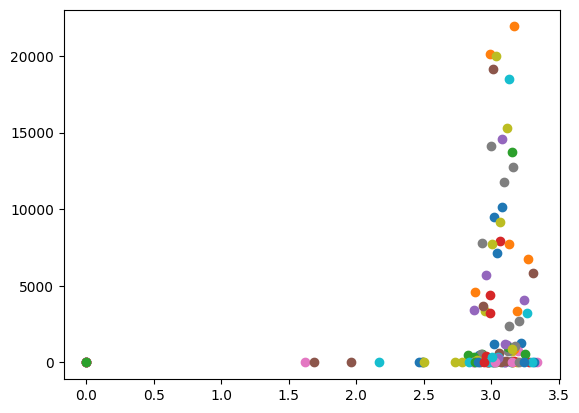

In [23]:
for item in results:
    plt.plot(results[item].entropy, min(results[item].test_loss), 'o')